# Pre-class: Monday Morning — Data Without Labels
**⏱ This pre-class notebook takes approximately 15 minutes.**

---

## Scenario: Monday — Marcus's New Brief

It's the start of week 5 at NorthStar Retail. Friday last week Sarah presented her Random Forest model. Marcus signed off on shipping it to production. Then he said:

> *"Now — what about the customers who DON'T churn but also don't log in for a year? Can we find natural CLUSTERS of customer behaviour without labels?"*

This Monday morning Sarah opens her familiar `northstar_customers.csv` — same 10,000 customers as L03/L04 — but **drops the `churned` column**. From this week's perspective, there is no target. There are just *features*. She has to find structure that wasn't labelled in advance.

By Friday she has to:
1. Reduce the data to something visualisable.
2. Group customers into natural segments she can name and present.
3. Flag a "watch list" of unusual customers worth investigating.

**By the end of this notebook you will be able to:**
- Describe NorthStar's customer features (without referring to `churned`)
- Spot correlations between features
- Identify rows that look "different" to you — a gut-feel pre-check for the Isolation Forest notebook

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("✅ Libraries loaded — ready to explore")

✅ Libraries loaded — ready to explore


## Load the data and drop the label

The dataset is the same one from L03/L04. The DIFFERENCE is that this week we're treating `churned` as if it doesn't exist — to simulate the real-world case where you genuinely don't have labels.

In [2]:
df = pd.read_csv("data/northstar_customers.csv")

# Drop the target column — that's the whole point of unsupervised
features = df.drop(columns=["customer_id", "churned"])

print(f"Loaded: {len(df):,} customers × {features.shape[1]} features")
print(f"(Original target column 'churned' has been DROPPED for this week.)")
print()
features.head()

Loaded: 10,000 customers × 10 features
(Original target column 'churned' has been DROPPED for this week.)



,age,tenure_months,region,subscription_tier,num_purchases_quarter,avg_monthly_spend_gbp,returns_per_purchase,last_login_days_ago,avg_review_polarity,support_tickets_quarter
0,23,24,Ireland,free,4,57.13,0.051,NaN,NaN,1
1,66,15,London,free,6,37.11,0.028,2.0,NaN,2
2,59,37,South,free,3,18.12,0.022,65.0,0.914,2
3,45,48,Wales,free,6,82.67,0.180,19.0,NaN,2
4,45,19,South,basic,6,201.96,0.500,27.0,0.335,0


## Step 1 — What features do we have?

10 features. Most are numerical (age, tenure, spend, etc.). Two are categorical (region, subscription_tier). Two have missing values from L03 (`last_login_days_ago` and `avg_review_polarity`).

For most unsupervised methods, we'll need to handle missing values + scale numerics + encode categoricals before training. That's the same preprocessing pipeline we built in L03.

In [3]:
# Quick summary of each column
print("Feature types:")
print(features.dtypes)
print()
print("Missing values:")
missing = features.isna().sum()
print(missing[missing > 0])
print()
print("Numerical summary (excluding missing):")
print(features.describe(include="number").round(2))

Feature types:
age                          int64
tenure_months                int64
region                         str
subscription_tier              str
num_purchases_quarter        int64
avg_monthly_spend_gbp      float64
returns_per_purchase       float64
last_login_days_ago        float64
avg_review_polarity        float64
support_tickets_quarter      int64
dtype: object

Missing values:
last_login_days_ago     777
avg_review_polarity    3055
dtype: int64

Numerical summary (excluding missing):
            age  tenure_months  num_purchases_quarter  avg_monthly_spend_gbp  \
count  10000.00       10000.00               10000.00               10000.00   
mean      48.77          35.75                   6.02                  69.76   
std       18.10          21.10                   2.49                  55.97   
min       18.00           0.00                   0.00                   4.66   
25%       33.00          18.00                   4.00                  33.52   
50%       49.00

## Step 2 — Are there visible "groups"?

Before reaching for any algorithm, it's worth looking at the data with your own eyes. Natural clusters — if they exist — might already show up when you plot two features against each other.

This is also a useful **calibration step**: if we already see clean separation in a 2D plot, we might not need complex algorithms. If we can't see anything obvious, that tells us the structure lives in higher-dimensional space — and that's exactly the scenario PCA and K-Means are built for.

Let's plot a few feature pairs and see what the data looks like.

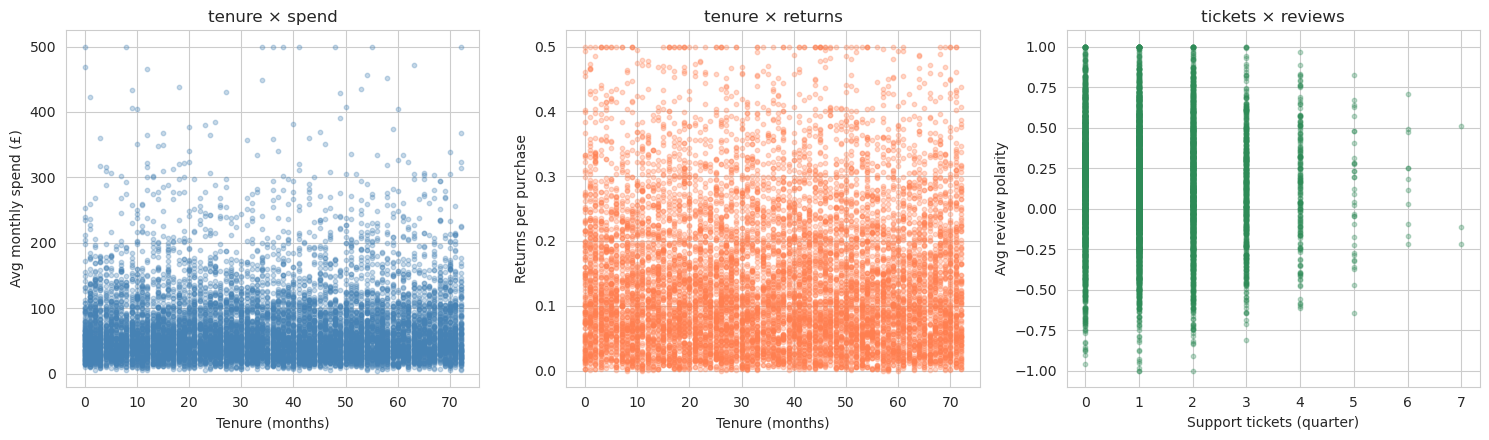

Eyeball question: in any plot, do you see distinct clusters? Or a smooth cloud?


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Plot 1: tenure vs spend
axes[0].scatter(features["tenure_months"], features["avg_monthly_spend_gbp"],
                alpha=0.3, s=10, color="steelblue")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Avg monthly spend (£)")
axes[0].set_title("tenure × spend")

# Plot 2: tenure vs returns
axes[1].scatter(features["tenure_months"], features["returns_per_purchase"],
                alpha=0.3, s=10, color="coral")
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Returns per purchase")
axes[1].set_title("tenure × returns")

# Plot 3: tickets vs reviews (handles NaN)
mask = features["avg_review_polarity"].notna()
axes[2].scatter(features.loc[mask, "support_tickets_quarter"],
                features.loc[mask, "avg_review_polarity"],
                alpha=0.3, s=10, color="seagreen")
axes[2].set_xlabel("Support tickets (quarter)")
axes[2].set_ylabel("Avg review polarity")
axes[2].set_title("tickets × reviews")

plt.tight_layout()
plt.show()

print("Eyeball question: in any plot, do you see distinct clusters? Or a smooth cloud?")

### 💡 What you should notice

- The plots show **smooth clouds**, not distinct clusters. That's normal — clusters in real data are **rarely** obvious in any two-feature view.
- The reason: if clusters differ across 10 features simultaneously, no single 2D slice will show clear separation. The clustering signal is spread across all dimensions at once.
- This is exactly why pure visual inspection is not sufficient for customer segmentation. We need tools that work in full feature space: **PCA** to reduce dimensions intelligently, and **K-Means** to find distance-based groupings.

## Step 3 — Correlations between features

Now that we've seen the data visually, let's be more systematic. The question: do any features carry **the same information** — i.e., are they correlated?

**Why does this matter?**  
When two features are strongly correlated, they're measuring the same underlying signal. Feeding both into a clustering algorithm doesn't give you twice the information — it *double-counts* that signal and inflates its influence on cluster boundaries. For instance, if customers who spend more also happen to buy more often, then `avg_monthly_spend_gbp` and `num_purchases_quarter` both say "this customer is highly active" — and the algorithm would over-weight that dimension when assigning clusters.

**What does this have to do with PCA?**  
PCA (Principal Component Analysis) is a dimensionality-reduction technique we'll use before clustering. It works by finding the directions of maximum variance in the data and projecting onto fewer axes. Crucially: **when two features are correlated, PCA merges them into a single component** — it removes the redundancy. By looking at correlations now, we can anticipate how much compression PCA will achieve:
- **Strong correlations → PCA compresses aggressively** (many features collapse into fewer components)
- **Weak correlations → PCA compresses less** (each feature carries independent information, so we keep more components)

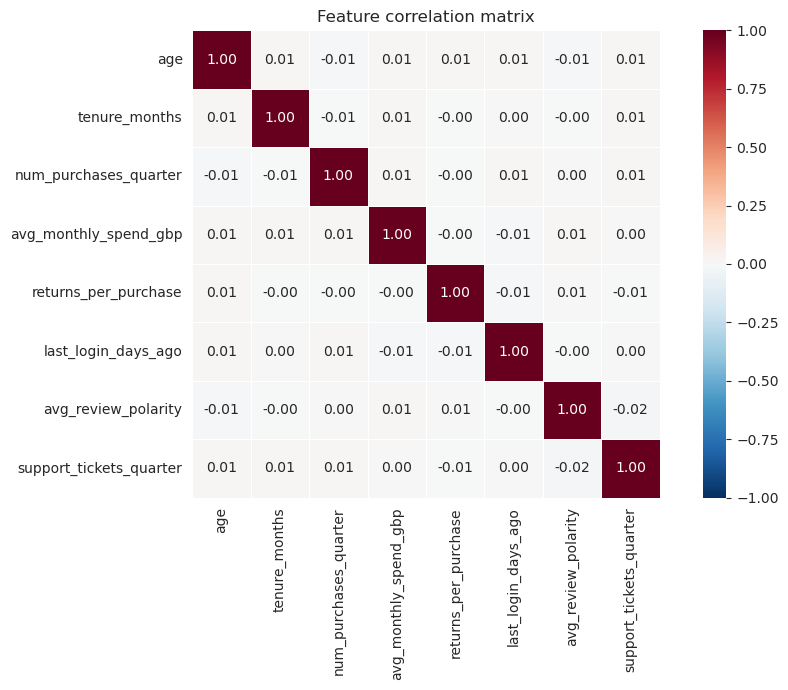

Notable correlations:
  avg_review_polarity      ↔ support_tickets_quarter   r = −0.02
  returns_per_purchase     ↔ last_login_days_ago       r = −0.01
  age                      ↔ avg_review_polarity       r = −0.01
  avg_monthly_spend_gbp    ↔ avg_review_polarity       r = +0.01
  age                      ↔ support_tickets_quarter   r = +0.01
  num_purchases_quarter    ↔ last_login_days_ago       r = +0.01
  num_purchases_quarter    ↔ support_tickets_quarter   r = +0.01
  tenure_months            ↔ avg_monthly_spend_gbp     r = +0.01
  age                      ↔ last_login_days_ago       r = +0.01
  tenure_months            ↔ support_tickets_quarter   r = +0.01
  age                      ↔ num_purchases_quarter     r = −0.01
  num_purchases_quarter    ↔ avg_monthly_spend_gbp     r = +0.01
  age                      ↔ avg_monthly_spend_gbp     r = +0.01
  age                      ↔ tenure_months             r = +0.01
  avg_monthly_spend_gbp    ↔ last_login_days_ago       r = −0.01
  a

In [8]:
# Correlation matrix for the numerical features
num_features = features.select_dtypes(include="number")
corr = num_features.corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

print("Notable correlations:")
# Find the top absolute correlations (excluding diagonal)
corr_pairs = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
#for (a, b), v in corr_pairs.head(5).items():
for (a, b), v in corr_pairs.items(): 
    sign = "+" if corr.loc[a, b] > 0 else "−"  #If the x-axis element and y-axis element is greater than "0", the sign is "+". Otherwise, "-".
    print(f"  {a:24s} ↔ {b:24s}  r = {sign}{abs(corr.loc[a, b]):.2f}")

### 💡 What you should notice

- **Correlations are mostly modest** — most features carry relatively independent information, which means PCA will compress only modestly here.
- The features with the strongest correlations are the ones PCA will most likely merge into a single component — those pairs were essentially saying the same thing.
- If correlations were very high (r > 0.8 across many pairs), PCA would dramatically reduce our 8 numeric features to perhaps 2–3 components. Here, we'll likely keep more, because each feature is contributing something unique.

**Note:** Some features might correlate with the dropped `churned` column in a supervised setting — but in unsupervised learning, we're only asking how features relate to *each other*, not to any outcome. That shift in framing is central to the unsupervised mindset.

## Step 4 — Eyeball some "unusual" customers (outliers / anomalies)

In machine learning, data points that sit far from the main population are called **outliers** or **anomalies** — customers who don't fit neatly into any natural segment.

**Why do outliers matter for clustering?**  
Most clustering algorithms (including K-Means) are sensitive to extreme values. A single outlier can pull a cluster centroid toward itself, distorting the shape and boundaries for the majority of "normal" customers. Think of it like a class average: one student who scores 1,000 will shift the mean even if every other student scores 50–70. The result is clusters that reflect the outlier's extremity rather than the genuine structure in the data.

Identifying and handling outliers before clustering keeps the algorithm focused on real segments. Even without an algorithm, some customers clearly look unusual. Let's find a few manually — the same intuition that Isolation Forest will later automate.

In [13]:
# Customers with the longest tenure AND highest support tickets
unusual_1 = features.sort_values(["tenure_months", "support_tickets_quarter"],
                                  ascending=[False, False]).head(10)
print("Long-tenured customers with high support-ticket counts:")
print(unusual_1.to_string())
print()
# Customers with high returns AND high spend (paradoxical)
unusual_2 = features[
    (features["returns_per_purchase"] > 0.3) &
    (features["avg_monthly_spend_gbp"] > 200)
].head(10)
print("High-spend AND high-return customers (unusual combination):")
print(unusual_2.to_string())

Long-tenured customers with high support-ticket counts:
      age  tenure_months    region subscription_tier  num_purchases_quarter  avg_monthly_spend_gbp  returns_per_purchase  last_login_days_ago  avg_review_polarity  support_tickets_quarter
2512   78             72    London              free                     11                 104.38                 0.065                 34.0                  NaN                        7
4305   66             72     North             basic                      3                  51.53                 0.307                  0.0               -0.098                        6
4491   30             72     South              free                     10                  61.27                 0.101                  5.0                0.122                        5
9903   64             72     South              free                      2                  51.94                 0.090                 35.0                0.173                        4
1435

### 💡 What you should notice

- **Unusual customers stand out on COMBINATIONS of features**, not on any one feature alone.
- Long tenure + many support tickets is unusual — most long-tenured customers are settled and rarely need support.
- High spend + high returns is unusual — typically high spenders keep what they buy.

**What is Isolation Forest, and how does it handle this?**  
Isolation Forest is an anomaly detection algorithm that finds outliers by building many random decision trees. The core insight: **anomalies are easier to isolate than normal points**.

Imagine randomly splitting a feature's range: an extreme data point gets cut off from the rest in just a few splits — because there's almost nothing nearby to separate it from. A normal point, buried in a dense cluster of similar customers, takes many more splits before it's isolated on its own. The algorithm measures the average number of splits (path length) needed to isolate each customer across hundreds of trees:

- **Short path length → likely an anomaly** (the point was quick to isolate — it's far from the crowd)
- **Long path length → likely normal** (the point was hard to separate — it blends in)

This is why Isolation Forest doesn't need you to define *what* makes a customer unusual. It discovers outliers across all features simultaneously — systematising exactly the kind of multi-feature reasoning we just did by hand.

## ✅ Section Summary

| What we did | What it tells us |
|---|---|
| **Dropped the `churned` label** | This week is genuinely unsupervised |
| **Eyeballed feature pairs (Step 2)** | No obvious visual clusters — real structure lives in higher-dimensional space, not visible in any single 2D slice |
| **Inspected correlations (Step 3)** | Features are mostly independent; correlated pairs reveal where PCA will merge dimensions — letting us anticipate how much compression to expect |
| **Eyeballed unusual customers (Step 4)** | Anomalies appear on feature COMBINATIONS, not single values — outliers can distort clustering if not handled first |

**Bring to class:**
1. Two features you'd expect to correlate (then we'll check if PCA agrees they're redundant).
2. One row from the head() that looked "different" to you (then we'll see if Isolation Forest agrees).
3. One question — anything from this notebook that didn't click.

---
**In class → Open `02_pca.ipynb` first.** That notebook builds the PCA dimensionality reduction.